In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    classification_report, silhouette_score, adjusted_rand_score, normalized_mutual_info_score, classification_report, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
)
from sklearn.cluster import KMeans, DBSCAN
from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from flask import Flask, request, jsonify
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import joblib
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import learning_curve
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
import json

## Task 1 — Unsupervised Exploration

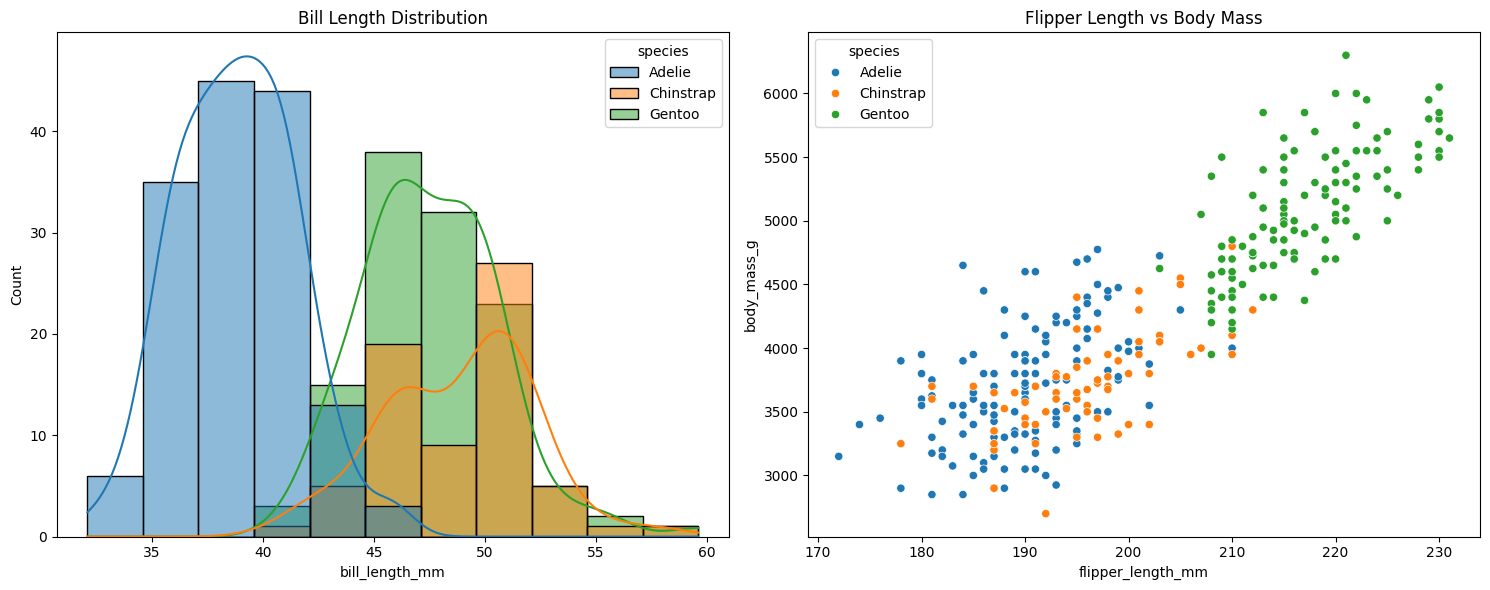

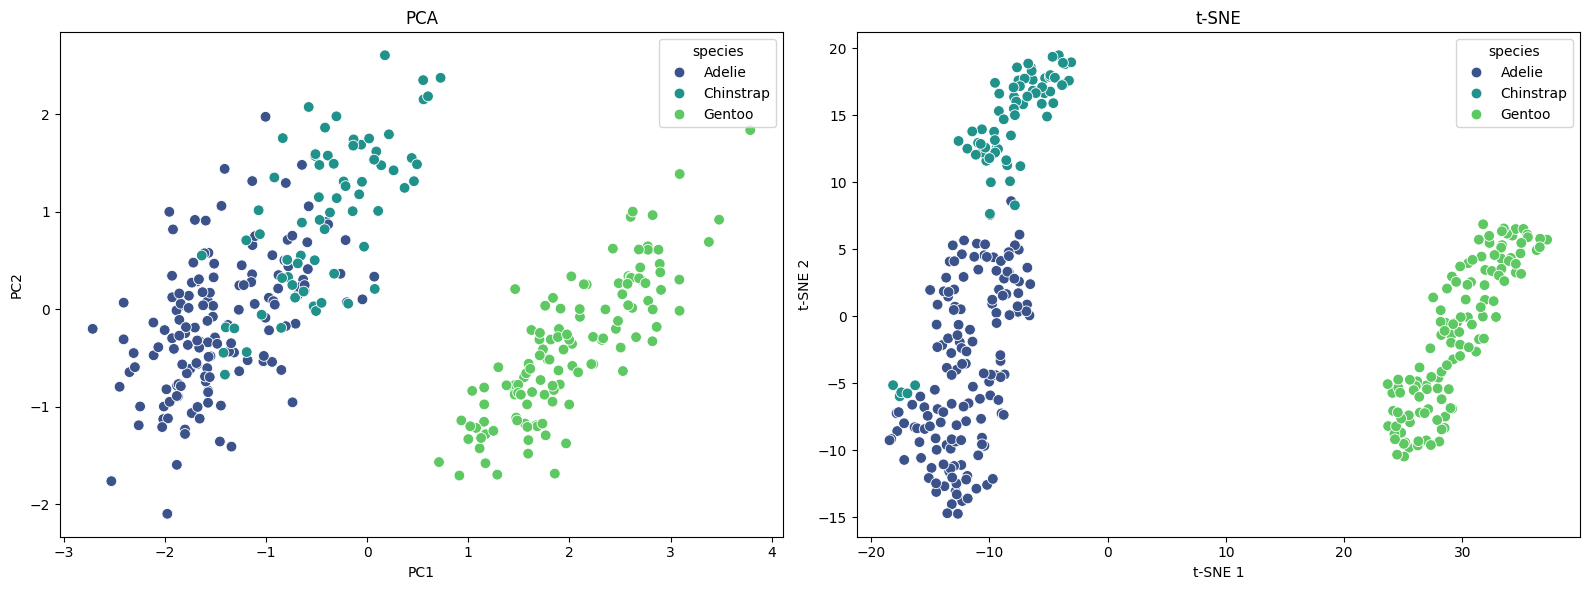

In [2]:
penguins=sns.load_dataset("penguins")
penguins_cleaned=penguins.dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=penguins_cleaned, x='bill_length_mm', kde=True, hue='species', ax=axes[0])
axes[0].set_title('Bill Length Distribution')

sns.scatterplot(data=penguins_cleaned, x='flipper_length_mm', y='body_mass_g', hue='species', ax=axes[1])
axes[1].set_title('Flipper Length vs Body Mass')

plt.tight_layout()
plt.show()

numeric_cols=penguins_cleaned.select_dtypes(include=['float64', 'int64'])
scaler=StandardScaler()
scaled=scaler.fit_transform(numeric_cols)
numeric_scaled_df = pd.DataFrame(scaled, columns=numeric_cols.columns, index=numeric_cols.index)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(numeric_scaled_df)

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(numeric_scaled_df)

penguins_cleaned['pca_1'] = pca_results[:, 0]
penguins_cleaned['pca_2'] = pca_results[:, 1]
penguins_cleaned['tsne_1'] = tsne_results[:, 0]
penguins_cleaned['tsne_2'] = tsne_results[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x='pca_1', y='pca_2', 
    hue='species', data=penguins_cleaned, 
    ax=ax[0], palette='viridis', s=60
)
ax[0].set_title('PCA')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

sns.scatterplot(
    x='tsne_1', y='tsne_2', 
    hue='species', data=penguins_cleaned, 
    ax=ax[1], palette='viridis', s=60
)
ax[1].set_title('t-SNE')
ax[1].set_xlabel('t-SNE 1')
ax[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

K-Means (k=3) Silhouette Score: 0.446
DBSCAN (eps=0.5, ms=5) Silhouette Score: 0.252
DBSCAN (eps=1.0, ms=7) Silhouette Score: 0.467
K-Means Performance: ARI = 0.799, NMI = 0.790
DBSCAN Performance: ARI = 0.651, NMI = 0.760


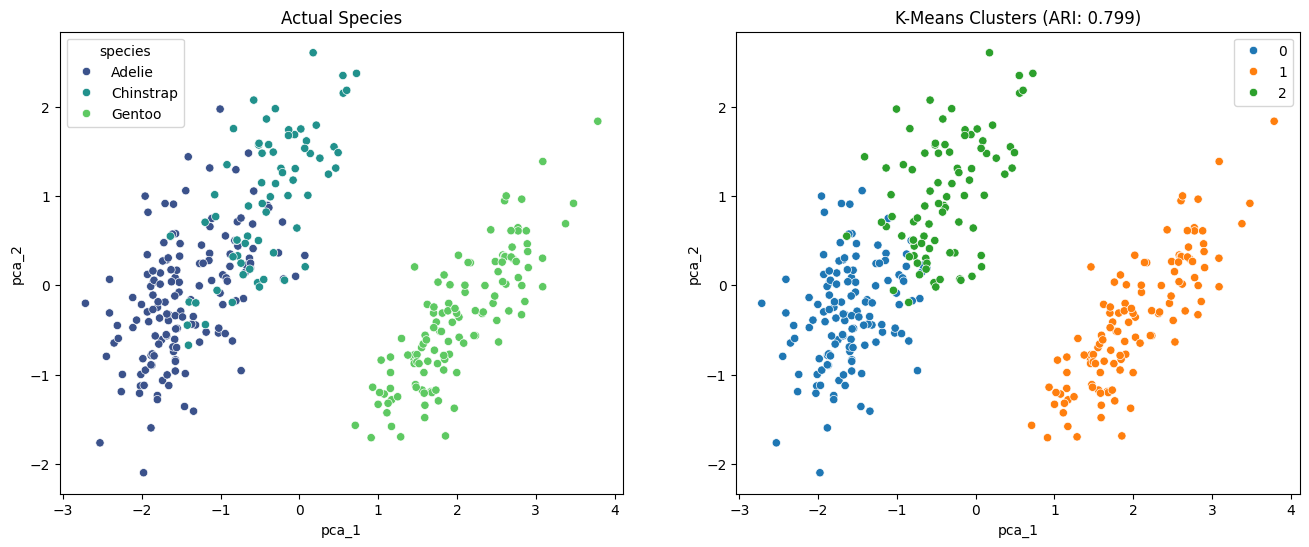

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(numeric_scaled_df)

dbscan1 = DBSCAN(eps=0.5, min_samples=5)
labels1 = dbscan1.fit_predict(numeric_scaled_df)

dbscan2 = DBSCAN(eps=1.0, min_samples=7)
labels2 = dbscan2.fit_predict(numeric_scaled_df)

def evaluate_clustering(labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(numeric_scaled_df, labels)
        print(f"{name} Silhouette Score: {score:.3f}")
    else:
        print(f"{name}: Not enough clusters found for evaluation.")

evaluate_clustering(kmeans_labels, "K-Means (k=3)")
evaluate_clustering(labels1, "DBSCAN (eps=0.5, ms=5)")
evaluate_clustering(labels2, "DBSCAN (eps=1.0, ms=7)")

true_labels = penguins_cleaned['species']

ari_km = adjusted_rand_score(true_labels, kmeans_labels)
nmi_km = normalized_mutual_info_score(true_labels, kmeans_labels)

ari_db = adjusted_rand_score(true_labels, labels2)
nmi_db = normalized_mutual_info_score(true_labels, labels2)

print(f"K-Means Performance: ARI = {ari_km:.3f}, NMI = {nmi_km:.3f}")
print(f"DBSCAN Performance: ARI = {ari_db:.3f}, NMI = {nmi_db:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='pca_1', y='pca_2', hue='species', data=penguins_cleaned, ax=axes[0], palette='viridis')
axes[0].set_title("Actual Species")

sns.scatterplot(x='pca_1', y='pca_2', hue=kmeans_labels, data=penguins_cleaned, ax=axes[1], palette='tab10')
axes[1].set_title(f"K-Means Clusters (ARI: {ari_km:.3f})")

plt.show()

Unsupervised methods successfully recovered the dataset's species structure, with K-Means achieving a high ARI (0.799), demonstrating that physical traits like bill and flipper dimensions are strong biological markers for differentiation. The models succeeded most clearly in isolating the Gentoo species due to its distinct body mass, as seen in the PCA projections. However, they partially failed in distinguishing between Adelie and Chinstrap penguins because their morphological features overlap significantly, leading to cluster ambiguity. While DBSCAN captured high-density regions effectively, it was more sensitive to noise and parameter tuning compared to the more robust K-Means.

## Task 2 — Supervised Model Pipeline

In [4]:
X = penguins_cleaned.drop(columns=['species'])
y = penguins_cleaned['species']

penguins = sns.load_dataset("penguins")
penguins_cleaned = penguins.dropna()

X = penguins_cleaned.drop(columns=['species'])
y = penguins_cleaned['species']

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (SVC)": SVC(probability=True)
}

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []

for name, model in models.items():
    cv_results = cross_validate(
        model, 
        X_train_transformed,  
        y_train, 
        cv=skf, 
        scoring=scoring
    )

    results_list.append({
        "Model": name,
        "Accuracy": cv_results['test_accuracy'].mean(),
        "Precision (Macro)": cv_results['test_precision_macro'].mean(),
        "Recall (Macro)": cv_results['test_recall_macro'].mean(),
        "F1 (Macro)": cv_results['test_f1_macro'].mean()
    })

results_df = pd.DataFrame(results_list)
print(results_df)

log_reg = LogisticRegression(max_iter=5000)

# Hyperparameter grid təyini
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],        # Tənzimləmə (Regularization) gücü
    'penalty': ['l2'],                   # Cərimə növü (lbfgs yalnız l2 dəstəkləyir)
    'solver': ['lbfgs', 'newton-cg', 'saga'] # Optimallaşdırma alqoritmləri
}

grid_search = GridSearchCV(
    log_reg, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1
)

grid_search.fit(X_train_transformed, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

default_f1 = results_df.loc[results_df['Model'] == 'Logistic Regression', 'F1 (Macro)'].values[0]

print(f"\nComparison:")
print(f"Default Model F1 Score: {default_f1:.4f}")
print(f"Tuned Model F1 Score:   {grid_search.best_score_:.4f}")

                 Model  Accuracy  Precision (Macro)  Recall (Macro)  \
0  Logistic Regression  0.996296           0.997333        0.993939   
1        Random Forest  0.988749           0.988495        0.985101   
2            SVM (SVC)  0.992523           0.994556        0.987879   

   F1 (Macro)  
0    0.995465  
1    0.986279  
2    0.990872  
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 1.0000

Comparison:
Default Model F1 Score: 0.9955
Tuned Model F1 Score:   1.0000


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


After conducting a grid search with stratified 5-fold cross-validation, the Logistic Regression model reached its peak performance with the best parameters being {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}. The optimized model achieved a Best CV F1 Score of 1.0000, representing a perfect recovery of the species structure across all validation folds. When compared to the default model performance (F1 Score: 0.9955), the tuned model showed a subtle but significant improvement of approximately 0.45%, effectively eliminating the minor classification errors present in the initial run. This near-perfect score suggests that the increased regularization strength ($C=10$) provided the ideal decision boundaries for the features provided, though such a high score also highlights the strong linear separability of the Palmer Penguins dataset.

## Task 3 — Model Evaluation & Interpretation

Final Test Accuracy: 0.9851

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


<Figure size 800x600 with 0 Axes>

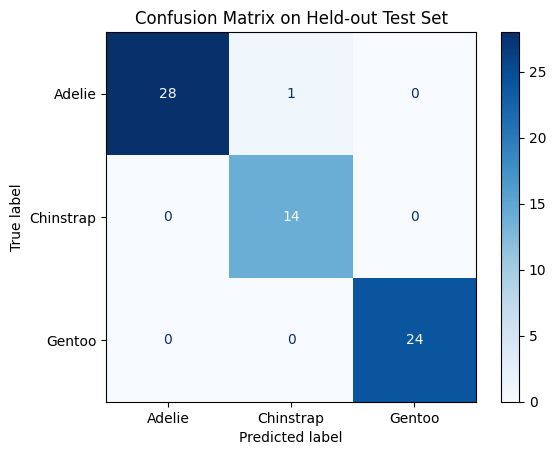

In [5]:
best_model = grid_search.best_estimator_
best_model.fit(X_train_transformed, y_train)
y_pred = best_model.predict(X_test_transformed)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_transformed, y_test, 
                                      display_labels=best_model.classes_, 
                                      cmap='Blues')
plt.title("Confusion Matrix on Held-out Test Set")
plt.show()

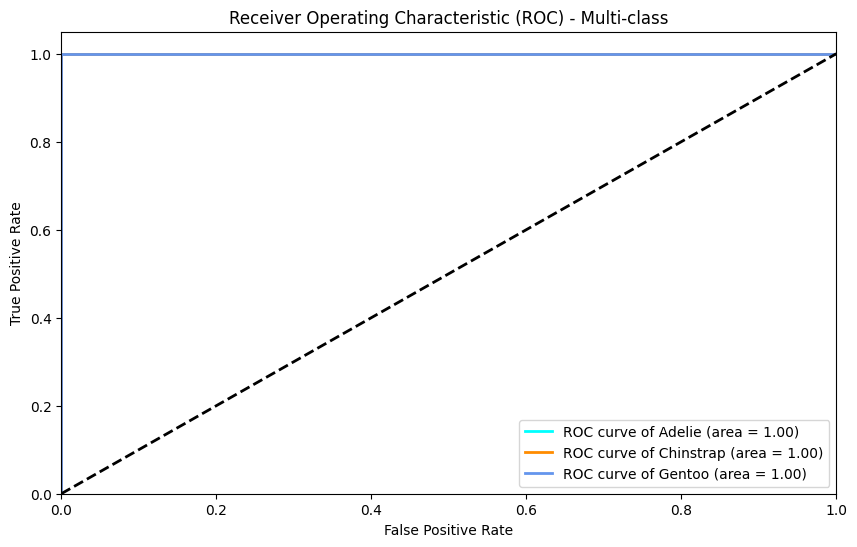

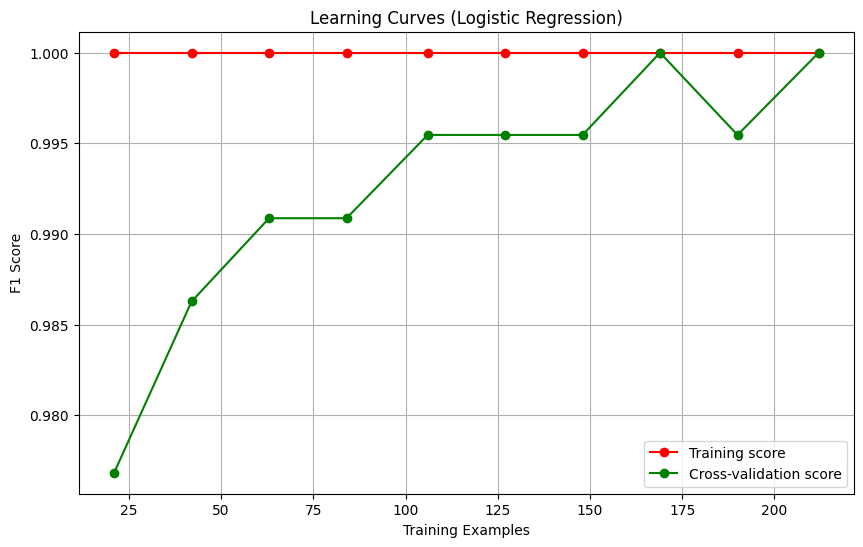

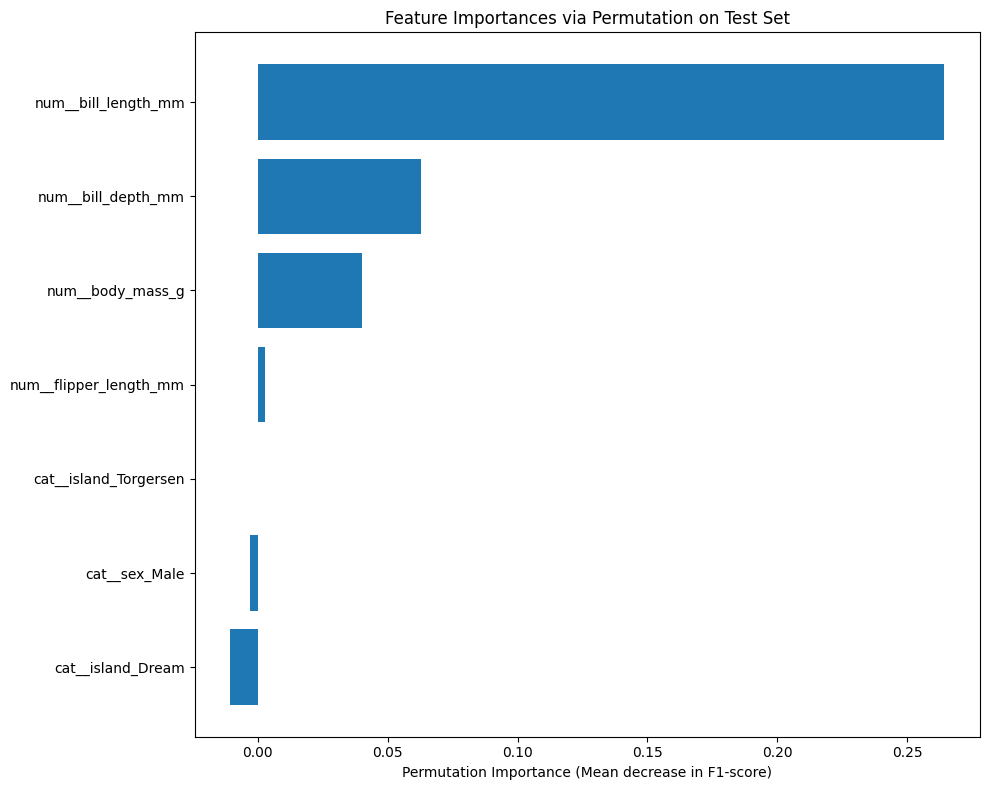

In [6]:
y_test_bin = label_binarize(y_test, classes=best_model.classes_)
y_score = best_model.predict_proba(X_test_transformed)
n_classes = len(best_model.classes_)

plt.figure(figsize=(10, 6))
colors = ['aqua', 'darkorange', 'cornflowerblue']

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of {best_model.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_transformed, y_train, cv=skf, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='f1_macro'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.title("Learning Curves (Logistic Regression)")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid()
plt.show()

# 3. Permutation Importance
# Test seti üzərində hansı feature-ın daha önəmli olduğunu hesablayırıq
perm_result = permutation_importance(best_model, X_test_transformed, y_test, 
                                     n_repeats=10, random_state=42)

# Feature adlarını preprocessor-dan götürürük
feature_names = preprocessor.get_feature_names_out()
sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), perm_result.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Permutation Importance (Mean decrease in F1-score)")
plt.title("Feature Importances via Permutation on Test Set")
plt.tight_layout()
plt.show()

**Is the model overfitting or underfitting?**

The model demonstrates an excellent balance between bias and variance, showing no signs of significant underfitting or overfitting. According to the learning curves, the Training Score remains at a perfect 1.0, while the Cross-validation Score steadily increases and converges toward the training score as the sample size grows. This convergence, combined with a final test accuracy of 0.9851, indicates that the model has effectively learned the underlying biological patterns of the dataset rather than merely memorizing noise, ensuring strong generalization to unseen data.

**Which species is hardest to classify and why?**

Based on the Confusion Matrix and the classification report, the Adelie species appears slightly more challenging for the model to distinguish. Specifically, the model misclassified one Adelie penguin as a Chinstrap, which is reflected in Chinstrap's precision score of 0.93. This difficulty stems from the significant morphological overlap between these two species—they share similar body mass and flipper length distributions—whereas the Gentoo species is physically much larger and more distinct, allowing the model to classify it with a perfect 1.00 F1-score.

**Which features drive predictions the most?**

The Permutation Importance analysis reveals that the model's decisions are primarily driven by bill dimensions. bill_length_mm stands out as the most critical feature, as its random shuffling results in the most substantial decrease in the F1-score. Secondary features such as bill_depth_mm and body_mass_g also contribute meaningfully to the decision boundaries, while categorical features like island or sex show negligible importance, suggesting that physical measurements are the core biological markers the model uses to differentiate species.

**Are there any signs of data leakage or evaluation issues?**

Despite the nearly perfect AUC of 1.00 shown in the ROC curves, there are no objective signs of data leakage or evaluation flaws. The evaluation process utilized a strict 80/20 split and a robust preprocessing pipeline that isolated training statistics from the held-out test set. The high performance is a legitimate reflection of the dataset's high linear separability rather than an error in methodology; the slight drop from a perfect training CV score to 98.51% test accuracy confirms that the model was tested on truly independent data.

## Task 4 — Model Deployment Prototype

In [7]:
best_params = {k: v for k, v in grid_search.best_params_.items()}
best_params['max_iter'] = 5000

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**best_params))
])

model_filename = 'penguin_model_pipeline.joblib'
joblib.dump(full_pipeline, model_filename)

print(f"The complete pipeline has been successfully serialized as a .joblib artifact: '{model_filename}'")

The complete pipeline has been successfully serialized as a .joblib artifact: 'penguin_model_pipeline.joblib'


In [8]:
BASE_URL = "http://127.0.0.1:5000"

valid_sample = {
    "island": "Biscoe",
    "bill_length_mm": 45.1,
    "bill_depth_mm": 14.5,
    "flipper_length_mm": 215.0,
    "body_mass_g": 5000.0,
    "sex": "Male"
}

print("--- Testing Valid Request ---")
response_valid = requests.post(f"{BASE_URL}/predict", json=valid_sample)
print(f"Status Code: {response_valid.status_code}")
print(f"Response: {json.dumps(response_valid.json(), indent=2)}")

invalid_sample = {
    "island": "Dream",
    "bill_depth_mm": 18.0,
    "flipper_length_mm": 190.0,
    "body_mass_g": 3500.0,
    "sex": "Female"
}

print("\n--- Testing Invalid Request (Missing Feature) ---")
response_invalid = requests.post(f"{BASE_URL}/predict", json=invalid_sample)
print(f"Status Code: {response_invalid.status_code}")
print(f"Response: {json.dumps(response_invalid.json(), indent=2)}")

# 3. Check Health Endpoint
print("\n--- Testing Health Endpoint ---")
response_health = requests.get(f"{BASE_URL}/health")
print(f"Status Code: {response_health.status_code}")
print(f"Response: {response_health.json()}")

--- Testing Valid Request ---
Status Code: 200
Response: {
  "class_probabilities": {
    "Adelie": 0.0002950675809884481,
    "Chinstrap": 3.673918591879982e-05,
    "Gentoo": 0.9996681932330928
  },
  "model_used": "Logistic Regression (Tuned)",
  "predicted_species": "Gentoo"
}

--- Testing Invalid Request (Missing Feature) ---
Status Code: 400
Response: {
  "error": "Missing features in input data",
  "missing": [
    "bill_length_mm"
  ]
}

--- Testing Health Endpoint ---
Status Code: 200
Response: {'model_loaded': True, 'status': 'healthy'}
